# Lesson 51: Career Simulation - Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Load Dataset
sales = pd.read_csv("lesson-51-source-files.csv")

# Dataset Exploration

In [3]:
sales.head()

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [5]:
# Check for missing values
sales.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [6]:
# Convert Date column to datetime
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%b-%y')

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7560 non-null   datetime64[ns]
 1   Time    7560 non-null   object        
 2   State   7560 non-null   object        
 3   Group   7560 non-null   object        
 4   Unit    7560 non-null   int64         
 5   Sales   7560 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 354.5+ KB


In [7]:
# Statistical summary
sales.describe()

,Date,Unit,Sales
count,7560,7560.000000,7560.000000
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201
min,2020-10-01 00:00:00,2.000000,5000.000000
25%,2020-10-23 00:00:00,8.000000,20000.000000
50%,2020-11-15 12:00:00,14.000000,35000.000000
75%,2020-12-08 00:00:00,26.000000,65000.000000
max,2020-12-30 00:00:00,65.000000,162500.000000
std,NaN,12.901403,32253.506944


# Exploratory Data Analysis

# State Sales Analysis

In [8]:
# Total sales by state
state_sales = sales.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.map('{:,.0f}'.format)

State
KY     105,565,000
NY      74,970,000
FL      58,857,500
CA      33,417,500
TX      22,760,000
AZ      22,580,000
 WA     22,152,500
Name: Sales, dtype: object

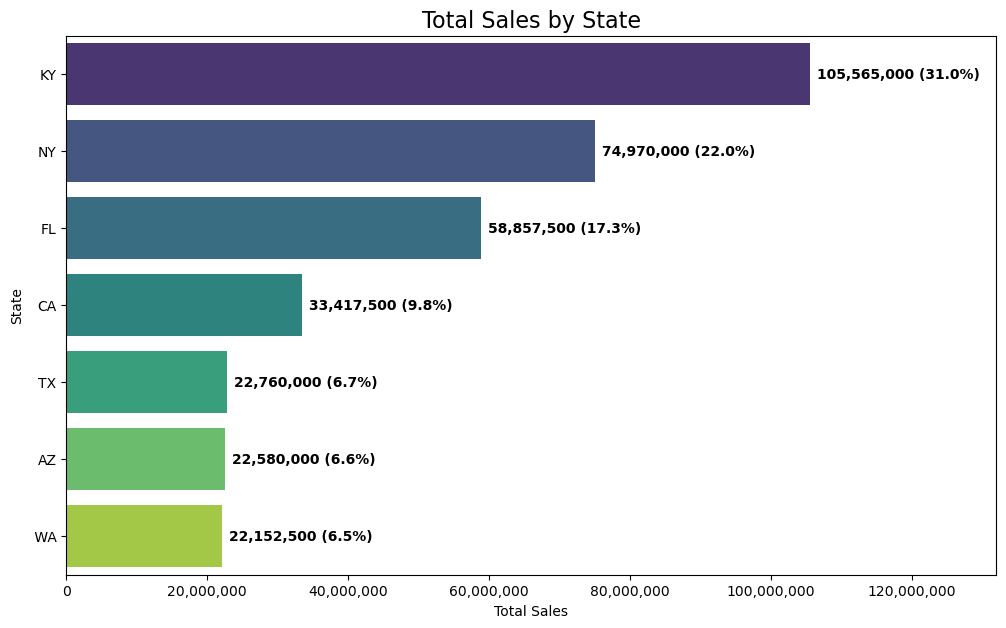

In [9]:
# Visualization of state sales

import matplotlib.ticker as ticker

plt.figure(figsize=(12,7))

ax = sns.barplot(
    y=state_sales.index,
    x=state_sales.values,
    hue=state_sales.index,
    palette='viridis',
    legend=False
)

plt.title('Total Sales by State', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('State')

# Format x-axis with commas
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Calculate total sales
total_sales = state_sales.sum()

# Add labels at end of bars
for i, value in enumerate(state_sales.values):

    percentage = (value / total_sales) * 100

    ax.text(
        value + 1000000,
        i,
        f'{value:,.0f} ({percentage:.1f}%)',
        va='center',
        fontsize=10,
        fontweight='bold'
    )
# Add extra space on right side for labels
plt.xlim(0, state_sales.max() * 1.25)

plt.show()

## Interpretation

Kentucky (KY) recorded the highest total sales in the dataset, while Washington (WA) showed the lowest sales. Interestingly, KY outperformed larger states such as California and Texas, which may suggest regional operational differences, store concentration, or other business factors influencing sales performance.

# Customer Group Analysis

In [10]:
# Total sales by customer group
group_sales = sales.groupby('Group')['Sales'].sum().sort_values(ascending=False)

group_sales.map('{:,.0f}'.format)

Group
Men        85,750,000
Women      85,442,500
Kids       85,072,500
Seniors    84,037,500
Name: Sales, dtype: object

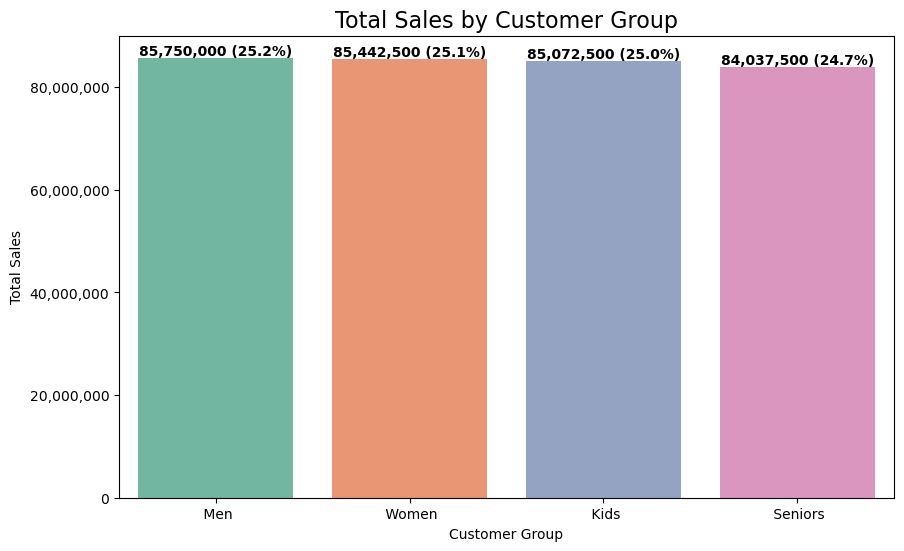

In [11]:
# Visualization of customer group sales
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=group_sales.index,
    y=group_sales.values,
    hue=group_sales.index,
    palette='Set2',
    legend=False
)

plt.title('Total Sales by Customer Group', fontsize=16)
plt.xlabel('Customer Group')
plt.ylabel('Total Sales')

# Format y-axis with commas
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Calculate percentages
total_sales = group_sales.sum()

# Add labels on top of bars
for i, value in enumerate(group_sales.values):

    percentage = (value / total_sales) * 100

    ax.text(
        i,
        value + 500000,
        f'{value:,.0f} ({percentage:.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

## Interpretation

Sales contributions across customer groups are highly balanced, with each segment contributing approximately 25% of total sales. Men generated the highest sales contribution at 25.2%, while Seniors contributed the lowest at 24.7%.

# Time-Based Sales Analysis

In [12]:
# Total sales by time of day
time_sales = sales.groupby('Time')['Sales'].sum().sort_values(ascending=False)


time_sales.map('{:,.0f}'.format)

Time
Morning      114,207,500
Afternoon    114,007,500
Evening      112,087,500
Name: Sales, dtype: object

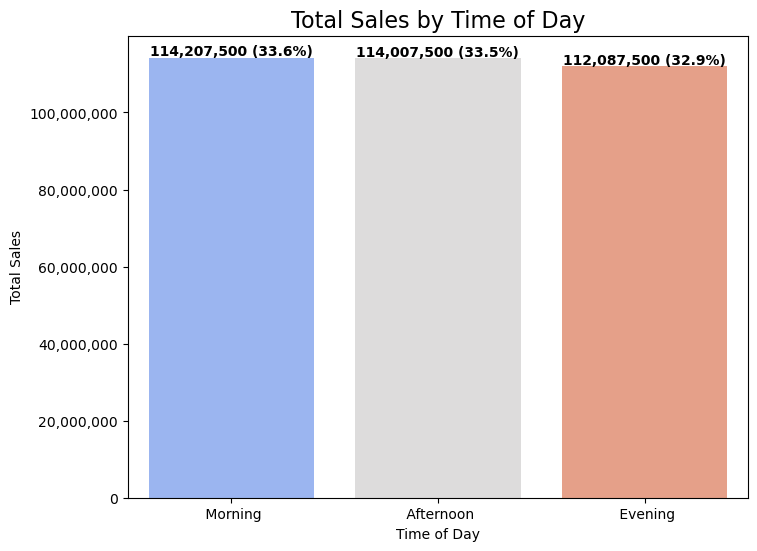

In [13]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=time_sales.index,
    y=time_sales.values,
    hue=time_sales.index,
    palette='coolwarm',
    legend=False
)

plt.title('Total Sales by Time of Day', fontsize=16)
plt.xlabel('Time of Day')
plt.ylabel('Total Sales')

# Format y-axis
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Percentages
total_sales = time_sales.sum()

for i, value in enumerate(time_sales.values):

    percentage = (value / total_sales) * 100

    ax.text(
        i,
        value + 500000,
        f'{value:,.0f} ({percentage:.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

## Interpretation

Sales performance across Morning, Afternoon, and Evening periods is highly balanced, with each time segment contributing approximately one-third of total sales. Morning sales were slightly higher at 33.6%, while Evening sales contributed the lowest at 32.9%.

# Sales Trend Over Time

In [14]:
# Daily sales trend
daily_sales = sales.groupby('Date')['Sales'].sum()

daily_sales.map('{:,.0f}'.format).head()

Date
2020-10-01    3,720,000
2020-10-02    3,715,000
2020-10-03    3,890,000
2020-10-04    3,720,000
2020-10-05    3,862,500
Name: Sales, dtype: object

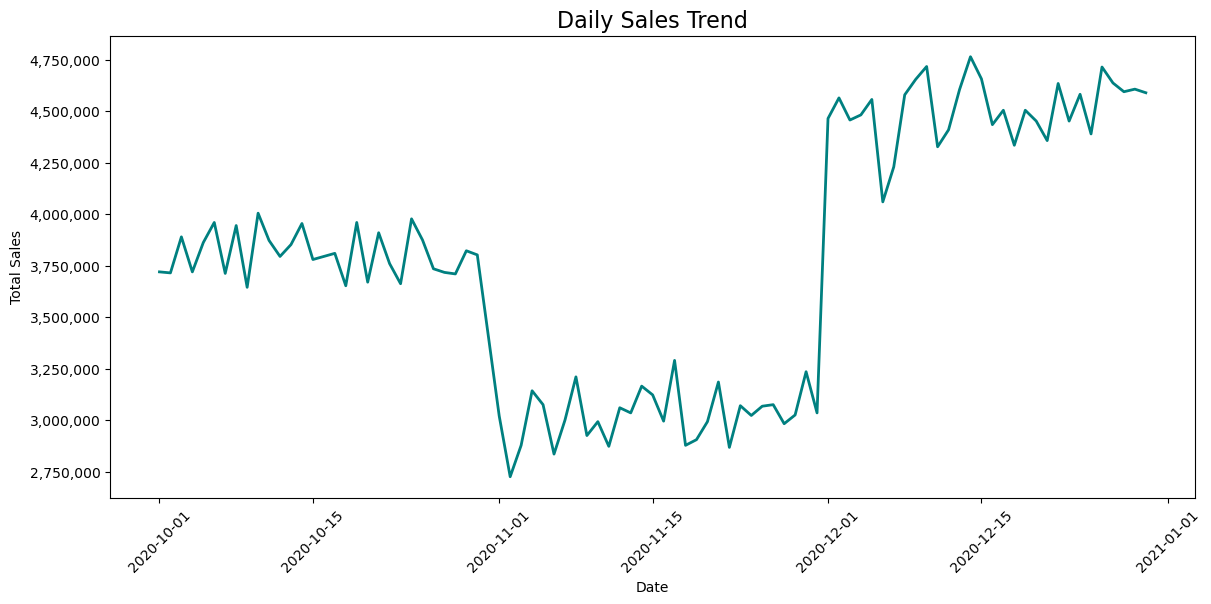

In [15]:

import matplotlib.ticker as ticker

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    x=daily_sales.index,
    y=daily_sales.values,
    color='teal',
    linewidth=2
)

plt.title('Daily Sales Trend', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales')

# Format y-axis with commas
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

plt.show()

## Interpretation

Daily sales remained relatively stable throughout October before experiencing a noticeable decline in early November. Sales recovered significantly beginning in December, reaching the highest levels during the final month of the dataset period.

The strong increase in December may indicate seasonal demand patterns, holiday shopping activity, or successful sales and marketing efforts during the end-of-year period.

# Correlation Analysis

In [16]:
# Correlation matrix
correlation = sales[['Unit', 'Sales']].corr()

correlation

,Unit,Sales
Unit,1.0,1.0
Sales,1.0,1.0


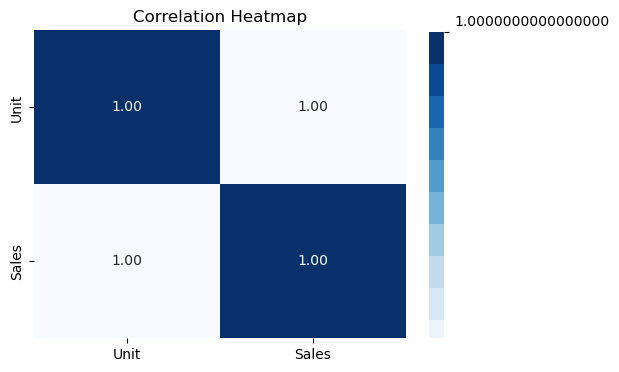

In [17]:
# Heatmap Visualization
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Interpretation

The heatmap shows a perfect positive correlation between Units Sold and Sales. This result is expected because sales revenue appears to increase proportionally with the number of units sold, indicating a fixed pricing structure (Sales = Unit × 2500) throughout the dataset.

# Conclusion and Recommendations

## Conclusion

The analysis showed that sales performance varied across states, with Kentucky generating the highest sales. Customer group and time-based sales were relatively balanced, while sales trends increased significantly during December.

## Recommendations

- Focus investments on high-performing states.
- Improve marketing strategies in lower-performing regions.
- Maintain balanced product offerings across customer groups.
- Prepare for increased seasonal demand during year-end periods.